#

# Análisis de ventas en la industria de cosméticos

##

##Objetivo
Analizar el comportamiento de las ventas en el sector de cosméticos para identificar patrones según el tiempo, el canal de venta, las marcas y los productos.

##Carga de datos

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving makeup_sales_dataset_2025.csv to makeup_sales_dataset_2025.csv


##

##Exploración inicial

In [ ]:
import pandas as pd

df = pd.read_csv(next(iter(uploaded)))
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


In [ ]:
df.describe ()



,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.00000
mean,250.500000,62.857760,25.416000,1586.37700
std,144.481833,32.609632,14.217426,1284.13365
min,1.000000,5.250000,1.000000,25.64000
25%,125.750000,35.512500,13.000000,536.67250
50%,250.500000,61.225000,26.000000,1241.12500
75%,375.250000,90.775000,37.000000,2345.87750
max,500.000000,119.930000,50.000000,5987.50000


##Limpieza de datos

In [ ]:
df.isnull().sum()

,0
Sale_ID,0
Date,0
Brand,0
Product_Type,0
Country,0
Sales_Channel,0
Payment_Method,0
Price_USD,0
Units_Sold,0
Revenue_USD,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Revenue_Check']= df['Price_USD']*df['Units_Sold']
df['Diferencia']= abs(df['Revenue_USD']- df['Revenue_Check'])
print (f"Registros con diferencia> $1:"
       f"{(df['Diferencia']>1).sum()}")


Registros con diferencia> $1:0


In [ ]:
df[revenue_check]

El dataset presenta una estructura limpia, sin valores nulos ni registros duplicados, lo que permite avanzar directamente con el análisis exploratorio. Las variables numéricas muestran una distribución coherente, sin outliers evidentes que afecten el análisis.

##

##Transformación de datos

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

In [ ]:
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD,Revenue_Check,Diferencia,Month,Month_Name,Year
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40,854.40,1.136868e-13,11,November,2025
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70,2898.70,0.000000e+00,2,February,2025
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64,1238.64,0.000000e+00,4,April,2025
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99,36.99,0.000000e+00,10,October,2025
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76,2531.76,4.547474e-13,4,April,2025


In [ ]:
ventas_mes = df.groupby('Month_Name')['Revenue_USD'].sum().reset_index()
ventas_mes

,Month_Name,Revenue_USD
0,April,67298.71
1,August,83296.77
2,December,62560.62
3,February,41654.67
4,January,63184.05
5,July,60675.03
6,June,98829.22
7,March,71169.11
8,May,69506.68
9,November,67251.71


In [ ]:
orden_meses = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

In [ ]:
ventas_mes['Month_Name'] = pd.Categorical(ventas_mes['Month_Name'], categories=orden_meses, ordered=True)

ventas_mes = ventas_mes.sort_values('Month_Name')

Se transformó la columna de fecha al formato datetime para poder trabajar correctamente con datos temporales. Además, se crearon nuevas variables como mes, nombre del mes y año, con el objetivo de facilitar el análisis de las ventas a lo largo del tiempo.

#

##Análisis


###Ventas por mes

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

In [ ]:
ventas_mes = df.groupby(
    ['Month', 'Month_Name']
)['Revenue_USD'].sum().reset_index()

ventas_mes = ventas_mes.sort_values(by='Month')

In [ ]:
ventas_mes = df.groupby('Month_Name')['Revenue_USD'].sum().reset_index()

In [ ]:
orden_meses = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

ventas_mes['Month_Name'] = pd.Categorical(
    ventas_mes['Month_Name'],
    categories=orden_meses,
    ordered=True
)

ventas_mes = ventas_mes.sort_values('Month_Name')

In [ ]:
import matplotlib.pyplot as plt



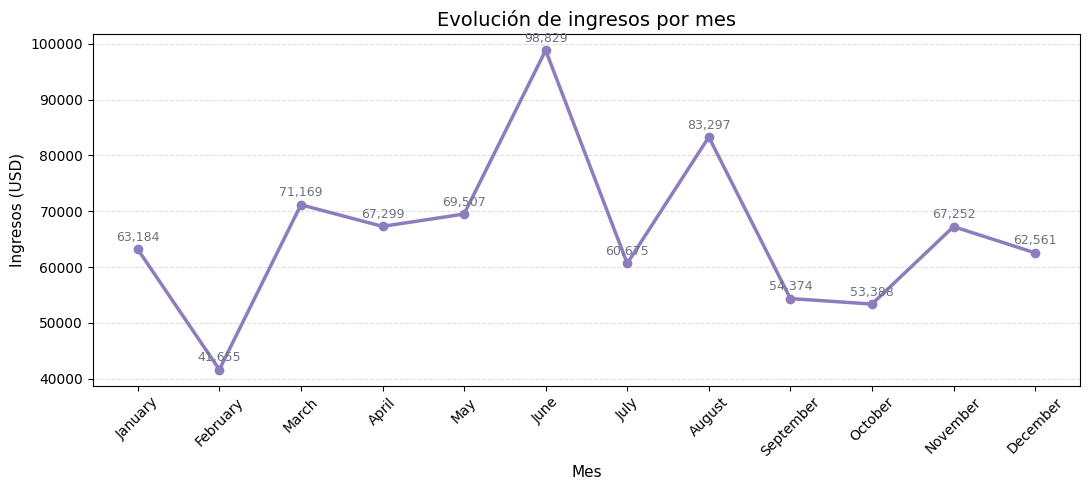

In [ ]:
plt.figure(figsize=(11,5))
plt.plot(
    ventas_mes['Month_Name'],
    ventas_mes['Revenue_USD'],
    marker='o',
    linewidth=2.5,
    color='#8E7DBE'
)

plt.title('Evolución de ingresos por mes', fontsize=14)
plt.xlabel('Mes', fontsize=11)
plt.ylabel('Ingresos (USD)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(ventas_mes['Revenue_USD']):
    plt.text(i, value + 1500, f"{value:,.0f}", ha='center', fontsize=9, color='#6B7280')

plt.tight_layout()
plt.show()

Las ventas no son constantes durante el año. Junio es el mes con mayor nivel de ingresos, mientras que febrero presenta el valor más bajo. Luego del pico de junio, se observa una caída en julio y una recuperación hacia fin de año.

###Ventas por canal

In [ ]:
ventas_canal = df.groupby(
    'Sales_Channel'
)['Revenue_USD'].sum().reset_index()

ventas_canal = ventas_canal.sort_values(
    by='Revenue_USD', ascending=False
)

In [ ]:
ventas_canal_tabla = ventas_canal.rename(columns={
    'Sales_Channel': 'Canal',
    'Revenue_USD': 'Ingresos'
})

ventas_canal_tabla['Ingresos'] = ventas_canal_tabla['Ingresos'].apply(lambda x: f"${x:,.0f}")

ventas_canal_tabla

,Canal,Ingresos
2,Online,"$224,883"
3,Retail Store,"$202,425"
1,Mall,"$189,931"
0,Beauty Salon,"$175,949"


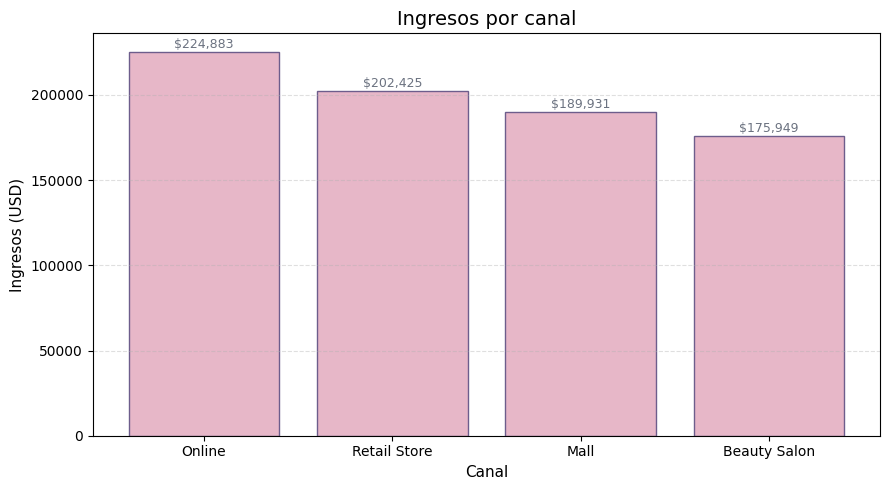

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

bars = plt.bar(
    ventas_canal['Sales_Channel'],
    ventas_canal['Revenue_USD'],
    color='#E7B7C8',
    edgecolor='#6D5D8C'
)

plt.title('Ingresos por canal', fontsize=14)
plt.xlabel('Canal', fontsize=11)
plt.ylabel('Ingresos (USD)', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# valores arriba de cada barra
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 2500,
        f"${y:,.0f}",
        ha='center',
        fontsize=9,
        color='#6B7280'
    )

plt.tight_layout()
plt.show()

Al analizar los ingresos por canal, se observa que el canal online es el que genera mayores ingresos, seguido por retail store y mall. En el último lugar se encuentra beauty salon, lo que muestra una menor participación de este canal dentro del total de ventas.

Esto indica una mayor concentración de las ventas en el canal digital, lo que podría reflejar cambios en los hábitos de consumo.

###Ventas por marca

In [ ]:
ventas_marca = df.groupby('Brand')['Revenue_USD'].sum().reset_index()

# ordenar de mayor a menor
ventas_marca = ventas_marca.sort_values(by='Revenue_USD', ascending=False)

# mostrar todas las marcas
plt.title('Ingresos por marca', fontsize=14)

ventas_marca


In [ ]:
ventas_marca_tabla = ventas_marca.rename(columns={
    'Brand': 'Marca',
    'Revenue_USD': 'Ingresos'
})

ventas_marca_tabla['Ingresos'] = ventas_marca_tabla['Ingresos'].apply(lambda x: f"${x:,.0f}")

ventas_marca_tabla

,Marca,Ingresos
5,MAC,"$155,246"
4,L'Oreal,"$123,593"
0,Dior,"$99,811"
2,Fenty Beauty,"$95,002"
7,NARS,"$88,793"
1,Estee Lauder,"$86,983"
3,Huda Beauty,"$76,357"
6,Maybelline,"$67,404"


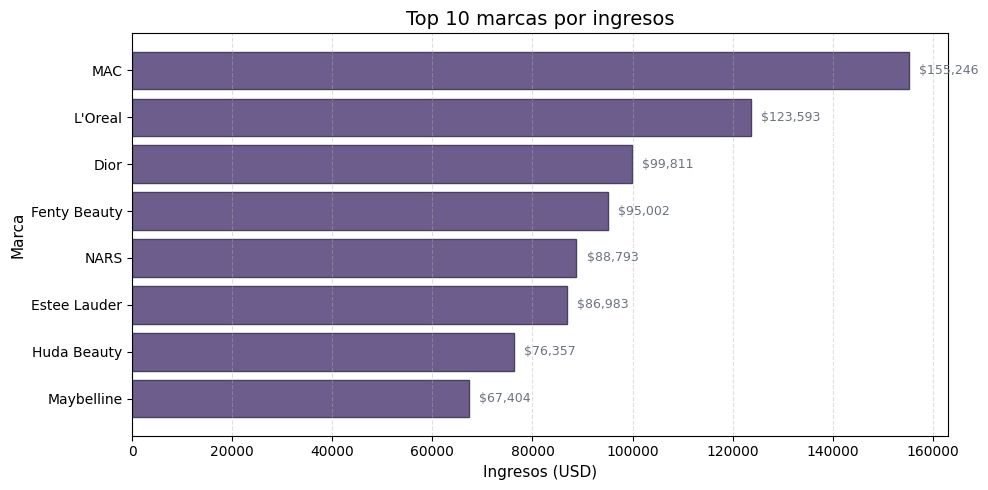

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.barh(
    ventas_marca['Brand'],
    ventas_marca['Revenue_USD'],
    color='#6D5D8C',
    edgecolor='#4B3F63'
)

plt.title('Top 10 marcas por ingresos', fontsize=14)
plt.xlabel('Ingresos (USD)', fontsize=11)
plt.ylabel('Marca', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.4)

# invertir para que la mejor quede arriba
plt.gca().invert_yaxis()

# agregar valores
for bar in bars:
    x = bar.get_width()
    plt.text(
        x + 2000,
        bar.get_y() + bar.get_height()/2,
        f"${x:,.0f}",
        va='center',
        fontsize=9,
        color='#6B7280'
    )

plt.tight_layout()
plt.show()

Al analizar los ingresos por marca, se observa que MAC es la que presenta el mayor nivel de ingresos, seguida por L’Oréal. Luego aparecen otras marcas con valores intermedios, mientras que las últimas posiciones muestran menores niveles de ventas.

Esto indica una concentración de ingresos en un grupo reducido de marcas, lo que podría reflejar una mayor preferencia del consumidor por determinadas marcas dentro del mercado.

###Productos más vendidos

In [ ]:
ventas_producto = df.groupby('Product_Type')['Units_Sold'].sum().reset_index()

# ordenar de mayor a menor
ventas_producto = ventas_producto.sort_values(by='Units_Sold', ascending=False)

ventas_producto


,Product_Type,Units_Sold
7,Mascara,1900
3,Eyeshadow,1716
2,Eyeliner,1646
6,Lipstick,1592
5,Highlighter,1526
4,Foundation,1523
0,Blush,1453
1,Concealer,1352


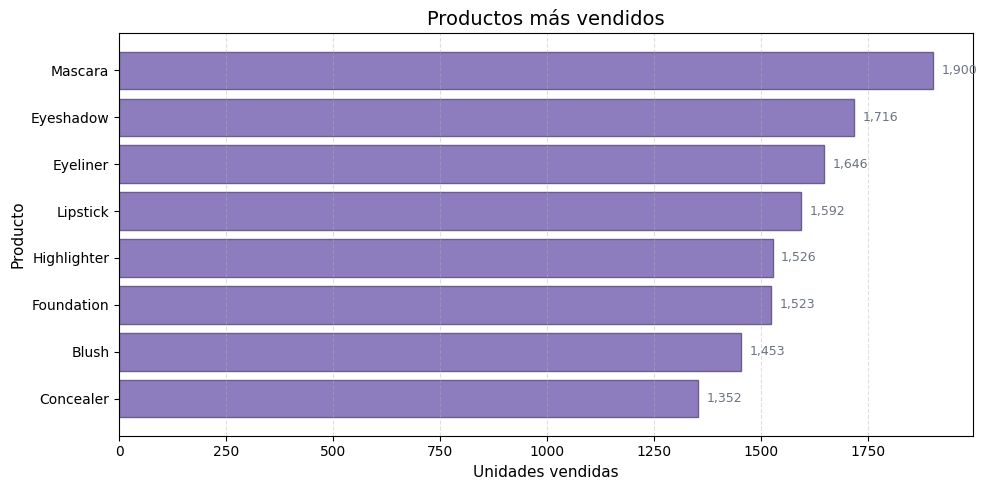

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.barh(
    ventas_producto['Product_Type'],
    ventas_producto['Units_Sold'],
    color='#8E7DBE',
    edgecolor='#6D5D8C'
)

plt.title('Productos más vendidos', fontsize=14)
plt.xlabel('Unidades vendidas', fontsize=11)
plt.ylabel('Producto', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.4)

# invertir para que el más vendido quede arriba
plt.gca().invert_yaxis()

# valores al final de cada barra
for bar in bars:
    x = bar.get_width()
    plt.text(
        x + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(x):,}",
        va='center',
        fontsize=9,
        color='#6B7280'
    )

plt.tight_layout()
plt.show()

Al analizar la cantidad de unidades vendidas por producto, se observa que mascara es el producto más vendido, seguido por eyeshadow y eyeliner. En el extremo inferior se encuentran concealer y blush, con menores niveles de ventas.

Esto muestra que la demanda se concentra en ciertos productos específicos dentro del mercado de cosméticos, lo que puede reflejar preferencias claras por parte de los consumidores.

##

##KPIs principales

In [ ]:
# KPIs
total_revenue = df['Revenue_USD'].sum()
total_units = df['Units_Sold'].sum()
precio_promedio = df['Price_USD'].mean()

print(f"Ingresos totales: ${total_revenue:,.0f}")
print(f"Unidades vendidas: {total_units:,}")
print(f"Precio promedio: ${precio_promedio:,.2f}")

Ingresos totales: $793,188
Unidades vendidas: 12,708
Precio promedio: $62.86


Para sintetizar el análisis se definieron indicadores clave que permiten evaluar el desempeño general del dataset. En primer lugar, los ingresos totales reflejan el volumen económico generado por las ventas. En segundo lugar, la cantidad de unidades vendidas permite analizar el nivel de actividad comercial. Por último, el precio promedio aporta información sobre el valor medio de los productos vendidos.

Estos indicadores permiten tener una visión general del comportamiento del negocio y facilitan la interpretación de los resultados obtenidos.


#Conclusión
A partir del análisis realizado, se observa que las ventas en la industria de cosméticos presentan variaciones a lo largo del tiempo, con picos en determinados meses que evidencian cambios en el comportamiento de los ingresos.

El canal online se posiciona como el principal generador de ingresos, lo que refleja una fuerte presencia del comercio digital dentro del sector. Asimismo, se identifica una concentración de las ventas en un grupo reducido de marcas, siendo algunas de ellas claramente predominantes en el mercado.

En cuanto a los productos, se observa que la demanda se centra en categorías específicas, lo que sugiere preferencias definidas por parte de los consumidores.

En conjunto, los resultados permiten comprender mejor el comportamiento del mercado y constituyen una base útil para la toma de decisiones orientadas a potenciar las ventas y optimizar la estrategia comercial.